# 07. R-R Features

Calculate R-R features and feed them into the CNN to see if it improves the f1-score.

## Load and Process data

In [1]:
from src.data_loader import load_dataset
import numpy as np

X_train, y_train, peaks_train, rr_train, \
X_test,  y_test,  peaks_test,  rr_test = load_dataset('../data/raw')

np.savez(
    '../data/processed/beats_split_with_rr.npz',
    X_train=X_train, y_train=y_train, rr_train=rr_train,
    X_test=X_test,   y_test=y_test,   rr_test=rr_test
)

print(f'X_train:  {X_train.shape}')
print(f'rr_train: {rr_train.shape}')
print(f'X_test:   {X_test.shape}')
print(f'rr_test:  {rr_test.shape}')


X_train:  (50977, 360)
rr_train: (50977, 3)
X_test:   (49668, 360)
rr_test:  (49668, 3)


In [2]:
print('Sample RR features (pre_rr, post_rr, ratio):')
print(rr_train[:5])
print(f'\nMean pre_rr:  {rr_train[:, 0].mean():.3f}s')
print(f'Mean post_rr: {rr_train[:, 1].mean():.3f}s')
print(f'Mean ratio:   {rr_train[:, 2].mean():.3f}')

Sample RR features (pre_rr, post_rr, ratio):
[[0.86944443 0.875      0.8980464 ]
 [0.875      0.89166665 0.9037847 ]
 [0.89166665 0.93333334 0.92099965]
 [0.93333334 0.95555556 0.964037  ]
 [0.95555556 0.9        0.9869903 ]]

Mean pre_rr:  0.778s
Mean post_rr: 0.779s
Mean ratio:   1.000


In [4]:
# Let's look at S and V classes separately
s_rr = rr_train[y_train == 1]  # S class
v_rr = rr_train[y_train == 2]  # V class
print(f'\nS class - Mean pre_rr: {s_rr[:, 0].mean():.3f}s, Mean post_rr: {s_rr[:, 1].mean():.3f}s, Mean ratio: {s_rr[:, 2].mean():.3f}')
print(f'V class - Mean pre_rr: {v_rr[:, 0].mean():.3f}s, Mean post_rr: {v_rr[:, 1].mean():.3f}s, Mean ratio: {v_rr[:, 2].mean():.3f}')



S class - Mean pre_rr: 0.506s, Mean post_rr: 0.692s, Mean ratio: 0.670
V class - Mean pre_rr: 0.574s, Mean post_rr: 0.897s, Mean ratio: 0.767


## Load New Model

In [1]:
from src.model import ECGNetRR
import torch

model = ECGNetRR()
beats = torch.randn(64, 1, 360)
rr    = torch.randn(64, 3)
print(model(beats, rr).shape)  # expect torch.Size([64, 5])

torch.Size([64, 5])


## DataLoaders

In [6]:
# Create data loaders that return both beats and RR features
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

#Load data from the .npz file
data = np.load('../data/processed/beats_split_with_rr.npz')
X_train = data['X_train']
y_train = data['y_train']
rr_train = data['rr_train']
X_test  = data['X_test']
y_test  = data['y_test']
rr_test  = data['rr_test']

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1),  # (N, 1, 360)
                         torch.tensor(rr_train, dtype=torch.float32),        # (N, 3)
                         torch.tensor(y_train, dtype=torch.long))          # (N,)
test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1),
                         torch.tensor(rr_test, dtype=torch.float32),
                         torch.tensor(y_test, dtype=torch.long))   

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

## Weighted Loss

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3, 4]),
    y=y_train
)
print(weights)

[2.22490398e-01 1.08116649e+01 2.69149947e+00 2.46265700e+01
 1.27442500e+03]


## Training

In [9]:
from torch import nn

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model     = ECGNetRR().to(device)
weight   = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Device: {device}')

Device: mps


In [11]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, rr_batch, y_batch in train_loader:
        # 1. move to device
        X_batch = X_batch.to(device)
        rr_batch = rr_batch.to(device)
        y_batch = y_batch.to(device)
        # 2. zero gradients
        optimizer.zero_grad()
        # 3. forward pass
        y_pred = model(X_batch, rr_batch)
        # 4. compute loss
        loss = criterion(y_pred, y_batch)
        # 5. backward pass
        loss.backward()
        # 6. optimizer step
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    

Epoch [1/10], Loss: 1.2879
Epoch [2/10], Loss: 1.1149
Epoch [3/10], Loss: 1.0153
Epoch [4/10], Loss: 0.9668
Epoch [5/10], Loss: 0.8495
Epoch [6/10], Loss: 0.8369
Epoch [7/10], Loss: 0.8151
Epoch [8/10], Loss: 0.8082
Epoch [9/10], Loss: 0.7342
Epoch [10/10], Loss: 0.7288


## Evaluation

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import CLASS_NAMES

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, rr_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        rr_batch = rr_batch.to(device)
        preds   = model(X_batch, rr_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

           N       0.98      0.86      0.92     44218
           S       0.46      0.50      0.48      1836
           V       0.60      0.84      0.70      3219
           F       0.06      0.60      0.10       388
           Q       0.00      0.00      0.00         7

    accuracy                           0.85     49668
   macro avg       0.42      0.56      0.44     49668
weighted avg       0.93      0.85      0.88     49668



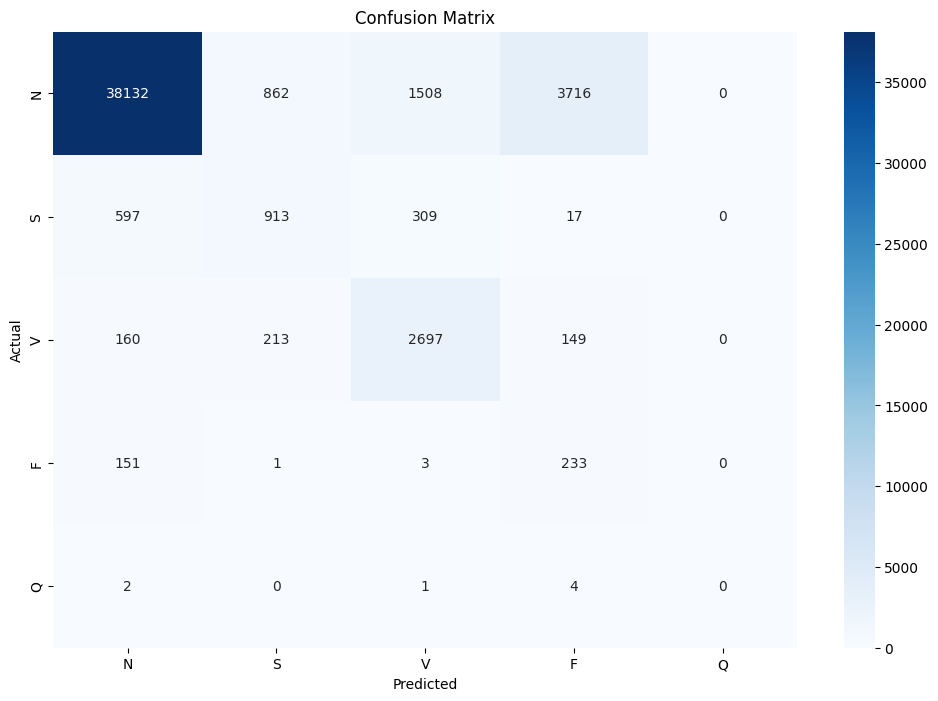

In [13]:
# PLot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('../results/rr_features_cm_raw.png', dpi=150, bbox_inches='tight')
plt.show()

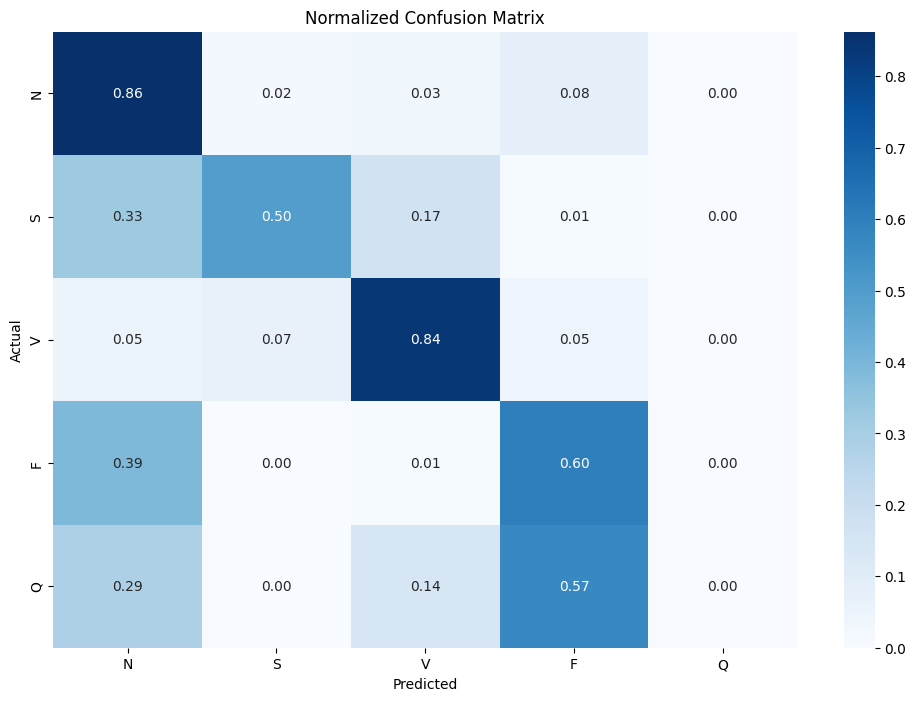

In [14]:
# PLot normalized confusion matrix

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.savefig('../results/rr_features_cm_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Save the model
torch.save(model.state_dict(), '../results/rr_model.pt')
